In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv(
    r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\data\APL_Logistics.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (180519, 40)


# Data Pre-processing

In [4]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0]

Customer Lname      8
Customer Zipcode    3
dtype: int64

In [5]:
# Fill missing values in Customer Lname with the most common name
df["Customer Lname"] = df["Customer Lname"].fillna(
    df["Customer Lname"].mode()[0]
)

# Fill missing values in Customer Zipcode with the most common zipcode
df["Customer Zipcode"] = df["Customer Zipcode"].fillna(
    df["Customer Zipcode"].mode()[0]
)

print("Missing values have been handled.")

Missing values have been handled.


In [6]:
# Check for completely duplicated rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [7]:
# Identify columns containing categorical/text data
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\3248949088.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [8]:
# Display unique values for each categorical column
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].unique())


--- Type ---
<ArrowStringArray>
['DEBIT', 'PAYMENT', 'TRANSFER', 'CASH']
Length: 4, dtype: str

--- Delivery Status ---
<ArrowStringArray>
['Late delivery', 'Shipping on time', 'Advance shipping', 'Shipping canceled']
Length: 4, dtype: str

--- Category Name ---
<ArrowStringArray>
[    'Cardio Equipment',        'Shop By Sport',         'Water Sports',
      'Women's Apparel',     'Camping & Hiking', 'Indoor/Outdoor Games',
              'Fishing',               'Cleats',          'Electronics',
       'Men's Footwear',          'Accessories',  'Fitness Accessories',
             'Trade-In',  'Baseball & Softball',          'Golf Gloves',
     'Men's Golf Clubs',           'Golf Balls',               'Hockey',
           'Golf Shoes',         'Boxing & MMA',         'Golf Apparel',
       'Girls' Apparel',      'As Seen on  TV!',             'Lacrosse',
     'Tennis & Racquet',     'Kids' Golf Clubs',    'Strength Training',
               'Soccer',    'Golf Bags & Carts',   'Hunting 

In [9]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [10]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [11]:
# Check for remaining missing values
missing_values_after = df.isnull().sum()

print("Remaining missing values:")
print(missing_values_after[missing_values_after > 0])

Remaining missing values:
Series([], dtype: int64)


In [12]:
# Check for leading or trailing spaces in categorical columns
for column in categorical_columns:
    space_values = df[column].astype(str).str.strip() != df[column].astype(str)
    
    if space_values.sum() > 0:
        print(f"{column}: {space_values.sum()} values contain extra spaces")

Category Name: 1475 values contain extra spaces
Customer Street: 1829 values contain extra spaces
Department Name: 362 values contain extra spaces
Order Region: 17925 values contain extra spaces
Product Name: 1774 values contain extra spaces


In [13]:
# Remove leading and trailing spaces from categorical columns
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

print("Categorical text values have been standardized.")

Categorical text values have been standardized.


In [14]:
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Dataset shape: (180519, 40)
Total missing values: 0
Total duplicate rows: 0


In [15]:
# Separate the target variable from the input features
y = df["Late_delivery_risk"]

# Create feature dataset by removing the target
X = df.drop("Late_delivery_risk", axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (180519, 39)
Target shape: (180519,)


In [16]:
# Find categorical columns in the feature dataset
categorical_features = X.select_dtypes(include="object").columns

print("Number of categorical features:", len(categorical_features))
print("\nCategorical features:")
print(categorical_features.tolist())

C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\857065701.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


Number of categorical features: 19

Categorical features:
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


In [17]:
# Check the number of unique values in each categorical feature
categorical_unique_counts = X[categorical_features].nunique().sort_values()

print(categorical_unique_counts)

Customer Country       2
Customer Segment       3
Type                   4
Delivery Status        4
Shipping Mode          4
Market                 5
Order Status           9
Department Name       11
Order Region          23
Customer State        46
Category Name         50
Product Name         118
Order Country        164
Customer City        563
Customer Fname       782
Order State         1089
Customer Lname      1109
Order City          3597
Customer Street     6953
dtype: int64


In [18]:
# Categorical features selected for One-Hot Encoding

categorical_features_to_encode = [
    "Type",
    "Customer Country",
    "Customer Segment",
    "Shipping Mode",
    "Market",
    "Department Name",
    "Order Region",
    "Customer State",
    "Category Name",
    "Product Name",
    "Order Country"
]

print("Categorical features selected for encoding:")
for column in categorical_features_to_encode:
    print(column)

Categorical features selected for encoding:
Type
Customer Country
Customer Segment
Shipping Mode
Market
Department Name
Order Region
Customer State
Category Name
Product Name
Order Country


In [19]:
# Identify numerical features, excluding the target

numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [20]:
from sklearn.preprocessing import OneHotEncoder

# Create the One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Encode the selected categorical features
encoded_categorical = encoder.fit_transform(
    X[categorical_features_to_encode]
)

print("Encoded categorical data shape:", encoded_categorical.shape)

Encoded categorical data shape: (180519, 430)


In [21]:
# Get the names of the newly created encoded columns
encoded_column_names = encoder.get_feature_names_out(
    categorical_features_to_encode
)

# Convert the encoded array into a DataFrame
encoded_categorical_df = pd.DataFrame(
    encoded_categorical,
    columns=encoded_column_names,
    index=X.index
)

print("Encoded DataFrame shape:", encoded_categorical_df.shape)

Encoded DataFrame shape: (180519, 430)


In [22]:
# Remove the original categorical columns
X_numerical = X.drop(columns=categorical_features_to_encode)

# Combine numerical features with the encoded categorical features
X_encoded = pd.concat(
    [X_numerical, encoded_categorical_df],
    axis=1
)

print("Final encoded feature shape:", X_encoded.shape)

Final encoded feature shape: (180519, 458)


In [23]:
# Check for remaining categorical columns
remaining_categorical = X_encoded.select_dtypes(
    include="object"
).columns

print("Remaining categorical columns:")
print(remaining_categorical.tolist())

Remaining categorical columns:
['Delivery Status', 'Customer City', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Order City', 'Order State', 'Order Status']


C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\3515039042.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_categorical = X_encoded.select_dtypes(


In [24]:
# Categorical columns that will not be used in the model
columns_to_remove = [
    "Delivery Status",
    "Customer City",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Order City",
    "Order State",
    "Order Status"
]

# Remove these columns from the feature dataset
X_encoded = X_encoded.drop(columns=columns_to_remove)

print("Feature shape after removing unsuitable columns:", X_encoded.shape)

Feature shape after removing unsuitable columns: (180519, 450)


In [25]:
# Check whether any text/categorical columns remain
remaining_categorical = X_encoded.select_dtypes(
    include="object"
).columns

print("Remaining categorical columns:")
print(remaining_categorical.tolist())

Remaining categorical columns:
[]


In [26]:
# Identify all numerical features in the encoded dataset
numerical_features_final = X_encoded.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical features:", len(numerical_features_final))
print("\nNumerical feature count:")
print(len(numerical_features_final))

Number of numerical features: 450

Numerical feature count:
450


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
# Create StandardScaler
scaler = StandardScaler()

# Scale all numerical features
X_scaled_array = scaler.fit_transform(X_encoded)

print("Scaled feature shape:", X_scaled_array.shape)

Scaled feature shape: (180519, 450)


In [29]:
# Convert scaled array back to a DataFrame
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_encoded.columns,
    index=X_encoded.index
)

print("Scaled dataset shape:", X_scaled.shape)

Scaled dataset shape: (180519, 450)


In [30]:
# Check mean and standard deviation after scaling
scaling_check = pd.DataFrame({
    "Mean": X_scaled[numerical_features_final].mean(),
    "Standard Deviation": X_scaled[numerical_features_final].std()
})

scaling_check.head(10)

,Mean,Standard Deviation
Days for shipping (real),7.824988e-17,1.000003
Days for shipment (scheduled),5.384599e-17,1.000003
Benefit per order,8.187110e-18,1.000003
Sales per customer,-1.763378e-17,1.000003
Category Id,1.007644e-16,1.000003
Customer Id,0.000000e+00,1.000003
Customer Zipcode,2.267200e-17,1.000003
Department Id,-2.015289e-17,1.000003
Latitude,-1.457935e-16,1.000003
Longitude,3.262248e-16,1.000003


In [31]:
# Check the number of observations in each target class
class_counts = y.value_counts().sort_index()

print("Class counts:")
print(class_counts)

Class counts:
Late_delivery_risk
0    81542
1    98977
Name: count, dtype: int64


In [32]:
# Calculate the percentage of each target class
class_percentages = y.value_counts(normalize=True).sort_index() * 100

print("Class percentages:")
print(class_percentages)

Class percentages:
Late_delivery_risk
0    45.170868
1    54.829132
Name: proportion, dtype: float64


# Feature Engineering



In [33]:
# Create Shipping Pressure Index
df["Shipping Pressure Index"] = (
    df["Order Item Quantity"] /
    (df["Days for shipment (scheduled)"] + 1)
)

# Display the new feature
df[
    [
        "Order Item Quantity",
        "Days for shipment (scheduled)",
        "Shipping Pressure Index"
    ]
].head()

,Order Item Quantity,Days for shipment (scheduled),Shipping Pressure Index
0,5,4,1.0
1,5,4,1.0
2,1,4,0.2
3,1,4,0.2
4,1,4,0.2


In [34]:
# Create shipping mode indicator variables
df["First_Class_Flag"] = (
    df["Shipping Mode"] == "First Class"
).astype(int)

df["Second_Class_Flag"] = (
    df["Shipping Mode"] == "Second Class"
).astype(int)

df["Same_Day_Flag"] = (
    df["Shipping Mode"] == "Same Day"
).astype(int)

df["Standard_Class_Flag"] = (
    df["Shipping Mode"] == "Standard Class"
).astype(int)

# Check the new features
df[
    [
        "Shipping Mode",
        "First_Class_Flag",
        "Second_Class_Flag",
        "Same_Day_Flag",
        "Standard_Class_Flag"
    ]
].head()

,Shipping Mode,First_Class_Flag,Second_Class_Flag,Same_Day_Flag,Standard_Class_Flag
0,Standard Class,0,0,0,1
1,Standard Class,0,0,0,1
2,Standard Class,0,0,0,1
3,Standard Class,0,0,0,1
4,Standard Class,0,0,0,1


In [35]:
# Calculate the number of orders in each region
region_order_counts = df["Order Region"].value_counts()

# Map regional order counts back to each order
df["Regional_Congestion_Indicator"] = (
    df["Order Region"].map(region_order_counts)
)

# Display the result
df[
    [
        "Order Region",
        "Regional_Congestion_Indicator"
    ]
].head()

,Order Region,Regional_Congestion_Indicator
0,South Asia,7731
1,Central America,28341
2,Central America,28341
3,East of USA,6915
4,East of USA,6915


In [36]:
# Normalize the components used for the complexity score
quantity_norm = (
    df["Order Item Quantity"] /
    df["Order Item Quantity"].max()
)

discount_norm = (
    df["Order Item Discount Rate"] /
    df["Order Item Discount Rate"].max()
)

pressure_norm = (
    df["Shipping Pressure Index"] /
    df["Shipping Pressure Index"].max()
)

# Create Order Complexity Score
df["Order_Complexity_Score"] = (
    quantity_norm +
    discount_norm +
    pressure_norm
) / 3

# Display the new feature
df[
    [
        "Order Item Quantity",
        "Order Item Discount Rate",
        "Shipping Pressure Index",
        "Order_Complexity_Score"
    ]
].head()

,Order Item Quantity,Order Item Discount Rate,Shipping Pressure Index,Order_Complexity_Score
0,5,0.06,1.0,0.480000
1,5,0.16,1.0,0.613333
2,1,0.09,0.2,0.200000
3,1,0.12,0.2,0.240000
4,1,0.20,0.2,0.346667


In [37]:
engineered_features = [
    "Shipping Pressure Index",
    "First_Class_Flag",
    "Second_Class_Flag",
    "Same_Day_Flag",
    "Standard_Class_Flag",
    "Regional_Congestion_Indicator",
    "Order_Complexity_Score"
]

print("Engineered features:")
for feature in engineered_features:
    print("✓", feature)

Engineered features:
✓ Shipping Pressure Index
✓ First_Class_Flag
✓ Second_Class_Flag
✓ Same_Day_Flag
✓ Standard_Class_Flag
✓ Regional_Congestion_Indicator
✓ Order_Complexity_Score


# Model Development

In [38]:
# Target variable
y = df["Late_delivery_risk"].copy()

print("Target shape:", y.shape)

Target shape: (180519,)


In [39]:
# Create a copy of the dataset for modeling
model_df = df.copy()

# Columns that should not be used as predictors
columns_to_drop = [
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer City",
    "Order City",
    "Order State",
    "Order Status"
]

# Remove unsuitable columns
X_model = model_df.drop(columns=columns_to_drop)

print("Model feature shape:", X_model.shape)

Model feature shape: (180519, 37)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (144415, 37)
Testing features: (36104, 37)
Training target: (144415,)
Testing target: (36104,)


In [41]:
# Identify categorical and numerical columns
categorical_features_model = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_features_model = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of categorical features:", len(categorical_features_model))
print("Number of numerical features:", len(numerical_features_model))

Number of categorical features: 11
Number of numerical features: 26


C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\144028410.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_model = X_train.select_dtypes(


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_model
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ]
)

In [43]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (144415, 456)
Processed testing data: (36104, 456)


## Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [45]:
# Predict class
y_pred_logistic = logistic_model.predict(X_test_processed)

# Predict probability of late delivery
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 late-delivery probabilities:")
print(y_prob_logistic[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 1 0]

First 10 late-delivery probabilities:
[0.28422665 0.36750554 0.27401602 0.2647333  0.36709598 0.35943172
 0.2549022  0.36587874 0.76786806 0.25538683]


In [46]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [47]:
# Calculate evaluation metrics
roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")

Logistic Regression Performance
--------------------------------
ROC-AUC  : 0.7430
Precision: 0.8463
Recall   : 0.5439
F1 Score : 0.6622


In [48]:
# Generate confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[14352  1956]
 [ 9029 10767]]


In [49]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "On-Time",
            "Late"
        ]
    )
)

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.61      0.88      0.72     16308
        Late       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



# Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [51]:
# Predict classes
y_pred_rf = random_forest_model.predict(X_test_processed)

# Predict probability of late delivery
y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 Random Forest probabilities:")
print(y_prob_rf[:10])

First 10 Random Forest predictions:
[0 0 0 0 1 0 0 0 1 0]

First 10 Random Forest probabilities:
[0.32  0.36  0.09  0.35  0.53  0.255 0.335 0.375 0.925 0.315]


In [52]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

print("Random Forest Performance")
print("-------------------------")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Random Forest Performance
-------------------------
ROC-AUC  : 0.8171
Precision: 0.8483
Recall   : 0.6158
F1 Score : 0.7136


In [53]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[14128  2180]
 [ 7606 12190]]


In [54]:
from xgboost import XGBClassifier

In [55]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [56]:
# Predict classes
y_pred_xgb = xgb_model.predict(X_test_processed)

# Predict probability of late delivery
y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 XGBoost predictions:")
print(y_pred_xgb[:10])

print("\nFirst 10 XGBoost probabilities:")
print(y_prob_xgb[:10])

First 10 XGBoost predictions:
[0 0 0 0 0 0 0 0 1 0]

First 10 XGBoost probabilities:
[0.35578302 0.38560626 0.2529788  0.32988647 0.45235467 0.36679187
 0.32041553 0.41720137 0.78988254 0.24924773]


In [57]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Performance")
print("-------------------")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")

XGBoost Performance
-------------------
ROC-AUC  : 0.7843
Precision: 0.8362
Recall   : 0.5755
F1 Score : 0.6817


In [58]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost Confusion Matrix:
[[14076  2232]
 [ 8404 11392]]


In [59]:
# Create model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_xgb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf,
        f1_xgb
    ]
})

model_comparison

,Model,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.742996,0.846263,0.543898,0.662197
1,Random Forest,0.817116,0.848295,0.615781,0.713575
2,XGBoost,0.784251,0.836171,0.575470,0.681747


In [60]:
model_comparison.round(4).reset_index(drop=True)

,Model,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.7430,0.8463,0.5439,0.6622
1,Random Forest,0.8171,0.8483,0.6158,0.7136
2,XGBoost,0.7843,0.8362,0.5755,0.6817


In [61]:
# Examine the distribution of predicted late-delivery probabilities
probability_summary = pd.Series(y_prob_rf).describe()

print(probability_summary)

count    36104.000000
mean         0.528352
std          0.249936
min          0.060000
25%          0.335000
50%          0.430000
75%          0.750000
max          1.000000
dtype: float64


In [62]:
# Display several predicted probabilities
print("Sample late-delivery probabilities:")
print(y_prob_rf[:20])

Sample late-delivery probabilities:
[0.32  0.36  0.09  0.35  0.53  0.255 0.335 0.375 0.925 0.315 0.195 0.985
 0.395 0.385 0.68  0.435 0.695 0.83  0.775 0.98 ]


# Risk Category Classification

In [63]:
def classify_risk(probability):
    if probability < 0.40:
        return "Low Risk"
    elif probability <= 0.70:
        return "Medium Risk"
    else:
        return "High Risk"


# Convert probabilities into risk categories
risk_categories = pd.Series(y_prob_rf).apply(classify_risk)

print("Risk category counts:")
print(risk_categories.value_counts())

Risk category counts:
Low Risk       15384
High Risk      10439
Medium Risk    10281
Name: count, dtype: int64


In [64]:
risk_distribution = (
    risk_categories.value_counts(normalize=True) * 100
)

print("Risk category percentages:")
print(risk_distribution.round(2))

Risk category percentages:
Low Risk       42.61
High Risk      28.91
Medium Risk    28.48
Name: proportion, dtype: float64


In [65]:
risk_results = pd.DataFrame({
    "Actual_Late_Delivery": y_test.values,
    "Late_Delivery_Probability": y_prob_rf,
    "Risk_Category": risk_categories.values
})

risk_results.head(10)

,Actual_Late_Delivery,Late_Delivery_Probability,Risk_Category
0,0,0.320,Low Risk
1,0,0.360,Low Risk
2,0,0.090,Low Risk
3,0,0.350,Low Risk
4,1,0.530,Medium Risk
5,0,0.255,Low Risk
6,1,0.335,Low Risk
7,0,0.375,Low Risk
8,1,0.925,High Risk
9,1,0.315,Low Risk


In [66]:
# Get the original test-set rows
test_orders = df.loc[X_test.index].copy()

# Add model risk outputs
test_orders["Late_Delivery_Probability"] = y_prob_rf
test_orders["Risk_Category"] = risk_categories.values

print("Test orders with risk predictions:")
print(
    test_orders[
        [
            "Late_delivery_risk",
            "Late_Delivery_Probability",
            "Risk_Category",
            "Shipping Mode",
            "Market",
            "Customer Segment"
        ]
    ].head(10)
)

Test orders with risk predictions:
        Late_delivery_risk  Late_Delivery_Probability Risk_Category  \
69318                    0                      0.320      Low Risk   
84032                    0                      0.360      Low Risk   
160369                   0                      0.090      Low Risk   
149768                   0                      0.350      Low Risk   
107905                   1                      0.530   Medium Risk   
130552                   0                      0.255      Low Risk   
153004                   1                      0.335      Low Risk   
70382                    0                      0.375      Low Risk   
149022                   1                      0.925     High Risk   
3231                     1                      0.315      Low Risk   

         Shipping Mode        Market Customer Segment  
69318   Standard Class         LATAM      Home Office  
84032   Standard Class        Europe        Corporate  
160369  Standar

In [67]:
high_risk_orders = test_orders[
    test_orders["Risk_Category"] == "High Risk"
].copy()

# Sort from highest risk to lowest risk
high_risk_orders = high_risk_orders.sort_values(
    "Late_Delivery_Probability",
    ascending=False
)

print("Number of high-risk orders:", len(high_risk_orders))

high_risk_orders[
    [
        "Late_Delivery_Probability",
        "Risk_Category",
        "Shipping Mode",
        "Market",
        "Customer Segment"
    ]
].head(20)

Number of high-risk orders: 10439


,Late_Delivery_Probability,Risk_Category,Shipping Mode,Market,Customer Segment
149490,1.0,High Risk,First Class,LATAM,Consumer
103264,1.0,High Risk,First Class,Europe,Consumer
86613,1.0,High Risk,First Class,Europe,Consumer
28546,1.0,High Risk,First Class,Pacific Asia,Consumer
88600,1.0,High Risk,First Class,LATAM,Corporate
116587,1.0,High Risk,First Class,Europe,Consumer
89398,1.0,High Risk,First Class,USCA,Consumer
141045,1.0,High Risk,First Class,Pacific Asia,Consumer
29740,1.0,High Risk,First Class,Africa,Consumer
136741,1.0,High Risk,First Class,LATAM,Corporate


# Explainability & Insights

In [68]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

Number of processed features: 456


In [69]:
# Get Random Forest feature importance
feature_importance = random_forest_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

# Display the top 20 features
importance_df.head(20)

,Feature,Importance
7,num__Latitude,0.042745
4,num__Customer Id,0.042673
9,num__Order Customer Id,0.042402
8,num__Longitude,0.039726
0,num__Days for shipment (scheduled),0.038135
17,num__Order Profit Per Order,0.037258
1,num__Benefit per order,0.037190
23,num__Standard_Class_Flag,0.036632
455,cat__Shipping Mode_Standard Class,0.035430
13,num__Order Item Profit Ratio,0.033638


In [70]:
# Features that represent meaningful operational factors
operational_keywords = [
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Total",
    "Order Profit Per Order",
    "Order Item Profit Ratio",
    "Product Price",
    "Shipping Pressure Index",
    "Regional_Congestion_Indicator",
    "Order_Complexity_Score",
    "First_Class_Flag",
    "Second_Class_Flag",
    "Same_Day_Flag",
    "Standard_Class_Flag",
    "Shipping Mode"
]

operational_importance = importance_df[
    importance_df["Feature"].apply(
        lambda x: any(keyword in x for keyword in operational_keywords)
    )
].copy()

operational_importance.head(20)

,Feature,Importance
0,num__Days for shipment (scheduled),0.038135
17,num__Order Profit Per Order,0.037258
1,num__Benefit per order,0.037190
23,num__Standard_Class_Flag,0.036632
455,cat__Shipping Mode_Standard Class,0.035430
13,num__Order Item Profit Ratio,0.033638
20,num__First_Class_Flag,0.031838
2,num__Sales per customer,0.028820
16,num__Order Item Total,0.028744
10,num__Order Item Discount,0.028421


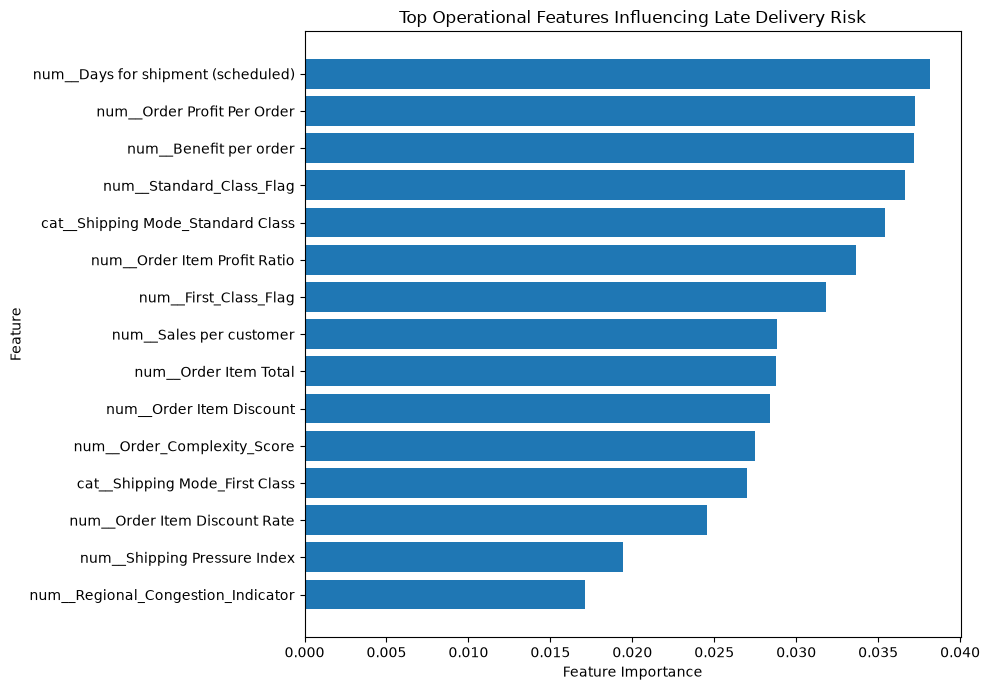

In [71]:
import matplotlib.pyplot as plt

top_operational_features = operational_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_operational_features["Feature"],
    top_operational_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Operational Features Influencing Late Delivery Risk")

plt.tight_layout()
plt.show()

In [72]:
# Identifier and location-proxy variables to remove
identifier_location_features = [
    "Customer Id",
    "Order Customer Id",
    "Category Id",
    "Department Id",
    "Customer Zipcode",
    "Latitude",
    "Longitude"
]

print("Features to remove:")
for feature in identifier_location_features:
    print("-", feature)

Features to remove:
- Customer Id
- Order Customer Id
- Category Id
- Department Id
- Customer Zipcode
- Latitude
- Longitude


In [73]:
# Create a copy of the modeling dataset
final_model_df = df.copy()

# Remove target, leakage-prone fields, personal/address fields,
# and identifier/location-proxy variables
final_columns_to_drop = [
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer City",
    "Order City",
    "Order State",
    "Order Status"
] + identifier_location_features

X_final = final_model_df.drop(columns=final_columns_to_drop)
y_final = df["Late_delivery_risk"].copy()

print("Final feature shape:", X_final.shape)
print("Target shape:", y_final.shape)

Final feature shape: (180519, 30)
Target shape: (180519,)


In [74]:
print("Remaining categorical features:")
print(X_final.select_dtypes(include="object").columns.tolist())

print("\nRemaining numerical features:")
print(X_final.select_dtypes(include=np.number).columns.tolist())

Remaining categorical features:
['Type', 'Category Name', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order Country', 'Order Region', 'Product Name', 'Shipping Mode']

Remaining numerical features:
['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'Shipping Pressure Index', 'First_Class_Flag', 'Second_Class_Flag', 'Same_Day_Flag', 'Standard_Class_Flag', 'Regional_Congestion_Indicator', 'Order_Complexity_Score']


C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\3083894454.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_final.select_dtypes(include="object").columns.tolist())


In [75]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print("Training data shape:", X_train_final.shape)
print("Testing data shape:", X_test_final.shape)

Training data shape: (144415, 30)
Testing data shape: (36104, 30)


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features_final = X_train_final.select_dtypes(
    include="object"
).columns.tolist()

numerical_features_final = X_train_final.select_dtypes(
    include=np.number
).columns.tolist()

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_final
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_final
        )
    ]
)

X_train_final_processed = final_preprocessor.fit_transform(X_train_final)
X_test_final_processed = final_preprocessor.transform(X_test_final)

print("Processed training shape:", X_train_final_processed.shape)
print("Processed testing shape:", X_test_final_processed.shape)

C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\1440571621.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_final = X_train_final.select_dtypes(


Processed training shape: (144415, 449)
Processed testing shape: (36104, 449)


In [77]:
from sklearn.ensemble import RandomForestClassifier

final_random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_random_forest.fit(
    X_train_final_processed,
    y_train_final
)

print("Final Random Forest training completed.")

Final Random Forest training completed.


In [78]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred_final = final_random_forest.predict(X_test_final_processed)
y_prob_final = final_random_forest.predict_proba(
    X_test_final_processed
)[:, 1]

roc_auc_final = roc_auc_score(y_test_final, y_prob_final)
precision_final = precision_score(y_test_final, y_pred_final)
recall_final = recall_score(y_test_final, y_pred_final)
f1_final = f1_score(y_test_final, y_pred_final)

cm_final = confusion_matrix(y_test_final, y_pred_final)

print("Final Random Forest Results")
print("---------------------------")
print(f"ROC-AUC   : {roc_auc_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1 Score  : {f1_final:.4f}")

print("\nConfusion Matrix:")
print(cm_final)

Final Random Forest Results
---------------------------
ROC-AUC   : 0.7598
Precision : 0.7947
Recall    : 0.6075
F1 Score  : 0.6886

Confusion Matrix:
[[13201  3107]
 [ 7769 12027]]


In [79]:
# Get feature names after preprocessing
final_feature_names = final_preprocessor.get_feature_names_out()

# Get Random Forest feature importance
final_feature_importance = final_random_forest.feature_importances_

# Create importance DataFrame
final_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_feature_importance
}).sort_values(
    "Importance",
    ascending=False
)

# Display top 20 features
final_importance_df.head(20)

,Feature,Importance
1,num__Benefit per order,0.058319
10,num__Order Profit Per Order,0.058298
6,num__Order Item Profit Ratio,0.052745
0,num__Days for shipment (scheduled),0.043707
9,num__Order Item Total,0.038841
2,num__Sales per customer,0.038603
3,num__Order Item Discount,0.038214
16,num__Standard_Class_Flag,0.037202
18,num__Order_Complexity_Score,0.036421
448,cat__Shipping Mode_Standard Class,0.035585


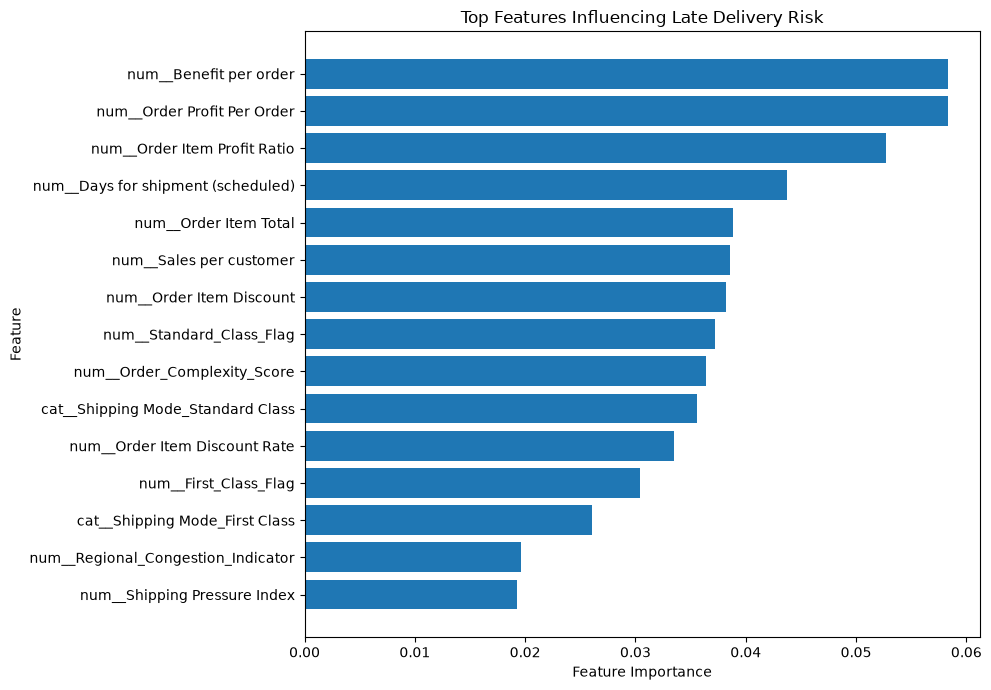

In [80]:
top_final_features = (
    final_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_final_features["Feature"],
    top_final_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Late Delivery Risk")

plt.tight_layout()
plt.show()

In [81]:
# Create risk categories based on predicted probability

def classify_final_risk(probability):
    if probability < 0.40:
        return "Low Risk"
    elif probability <= 0.70:
        return "Medium Risk"
    else:
        return "High Risk"


final_risk_categories = pd.Series(
    y_prob_final
).apply(classify_final_risk)

print(final_risk_categories.value_counts())

Low Risk       14949
Medium Risk    10776
High Risk      10379
Name: count, dtype: int64


In [82]:
# Get the original test orders
final_test_orders = df.loc[X_test_final.index].copy()

# Add prediction results
final_test_orders["Late_Delivery_Probability"] = y_prob_final
final_test_orders["Risk_Category"] = final_risk_categories.values

# Sort by predicted risk
final_test_orders = final_test_orders.sort_values(
    "Late_Delivery_Probability",
    ascending=False
)

print("Final test orders:", final_test_orders.shape)

final_test_orders[
    [
        "Late_Delivery_Probability",
        "Risk_Category",
        "Shipping Mode",
        "Days for shipment (scheduled)",
        "Order Item Quantity",
        "Order_Complexity_Score"
    ]
].head(10)

Final test orders: (36104, 49)


,Late_Delivery_Probability,Risk_Category,Shipping Mode,Days for shipment (scheduled),Order Item Quantity,Order_Complexity_Score
83479,1.0,High Risk,First Class,1,1,0.220000
87363,1.0,High Risk,First Class,1,2,0.320000
86751,1.0,High Risk,First Class,1,1,0.126667
2733,1.0,High Risk,First Class,1,1,0.180000
68117,1.0,High Risk,First Class,1,3,0.540000
85104,1.0,High Risk,First Class,1,1,0.433333
167699,1.0,High Risk,First Class,1,4,0.466667
33054,1.0,High Risk,First Class,1,1,0.153333
169489,1.0,High Risk,First Class,1,1,0.313333
23924,1.0,High Risk,First Class,1,1,0.366667


In [83]:
# Select the highest-risk order
high_risk_order = final_test_orders.iloc[0]

print("Highest-risk order:")
print(high_risk_order)

Highest-risk order:
Type                                                               DEBIT
Days for shipping (real)                                               2
Days for shipment (scheduled)                                          1
Benefit per order                                                   55.6
Sales per customer                                                118.29
Delivery Status                                            Late delivery
Late_delivery_risk                                                     1
Category Id                                                           18
Category Name                                             Men's Footwear
Customer City                                                     Caguas
Customer Country                                             Puerto Rico
Customer Fname                                                    Philip
Customer Id                                                         5971
Customer Lname                 

In [84]:
# Check the probability and predicted class for the selected order

highest_risk_index = X_test_final.index[
    y_prob_final.argmax()
]

highest_risk_position = list(X_test_final.index).index(
    highest_risk_index
)

print("Order index:", highest_risk_index)
print("Predicted probability:", y_prob_final[highest_risk_position])
print("Predicted class:", y_pred_final[highest_risk_position])

Order index: 171325
Predicted probability: 1.0
Predicted class: 1


In [85]:
# Select the highest-risk order from the test data
selected_order = X_test_final.loc[[highest_risk_index]].copy()

# Baseline prediction
baseline_probability = final_random_forest.predict_proba(
    final_preprocessor.transform(selected_order)
)[:, 1][0]

# Determine feature types
categorical_final = X_train_final.select_dtypes(
    include="object"
).columns.tolist()

numerical_final = X_train_final.select_dtypes(
    include=np.number
).columns.tolist()

local_results = []

# Test numerical features
for feature in numerical_final:
    modified_order = selected_order.copy()

    # Replace the feature with the training median
    modified_order[feature] = X_train_final[feature].median()

    modified_probability = final_random_forest.predict_proba(
        final_preprocessor.transform(modified_order)
    )[:, 1][0]

    local_results.append({
        "Feature": feature,
        "Original_Value": selected_order[feature].iloc[0],
        "Baseline_Probability": baseline_probability,
        "Modified_Probability": modified_probability,
        "Probability_Change": modified_probability - baseline_probability
    })


# Test categorical features
for feature in categorical_final:
    modified_order = selected_order.copy()

    # Replace the feature with the most common training value
    modified_order[feature] = X_train_final[feature].mode()[0]

    modified_probability = final_random_forest.predict_proba(
        final_preprocessor.transform(modified_order)
    )[:, 1][0]

    local_results.append({
        "Feature": feature,
        "Original_Value": selected_order[feature].iloc[0],
        "Baseline_Probability": baseline_probability,
        "Modified_Probability": modified_probability,
        "Probability_Change": modified_probability - baseline_probability
    })


local_explanation = pd.DataFrame(local_results)

# Sort by magnitude of probability change
local_explanation["Absolute_Change"] = (
    local_explanation["Probability_Change"].abs()
)

local_explanation = local_explanation.sort_values(
    "Absolute_Change",
    ascending=False
)

local_explanation.head(15)

C:\Users\hrush\AppData\Local\Temp\ipykernel_11180\3506377680.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_final = X_train_final.select_dtypes(


,Feature,Original_Value,Baseline_Probability,Modified_Probability,Probability_Change,Absolute_Change
29,Shipping Mode,First Class,1.0,0.770,-0.230,0.230
13,First_Class_Flag,1,1.0,0.820,-0.180,0.180
0,Days for shipment (scheduled),1,1.0,0.875,-0.125,0.125
16,Standard_Class_Flag,0,1.0,0.890,-0.110,0.110
12,Shipping Pressure Index,0.5,1.0,0.970,-0.030,0.030
1,Benefit per order,-39.14,1.0,0.990,-0.010,0.010
11,Product Price,199.99,1.0,0.995,-0.005,0.005
10,Order Profit Per Order,-39.14,1.0,0.995,-0.005,0.005
5,Order Item Product Price,199.99,1.0,1.000,0.000,0.000
4,Order Item Discount Rate,0.16,1.0,1.000,0.000,0.000


# Key Performance Indicators (KPIs)

In [86]:
# Overall KPI calculations

total_test_orders = len(final_test_orders)

high_risk_count = (
    final_test_orders["Risk_Category"] == "High Risk"
).sum()

medium_risk_count = (
    final_test_orders["Risk_Category"] == "Medium Risk"
).sum()

low_risk_count = (
    final_test_orders["Risk_Category"] == "Low Risk"
).sum()

average_late_probability = (
    final_test_orders["Late_Delivery_Probability"].mean()
)

high_risk_percentage = (
    high_risk_count / total_test_orders
) * 100

medium_risk_percentage = (
    medium_risk_count / total_test_orders
) * 100

low_risk_percentage = (
    low_risk_count / total_test_orders
) * 100


print("========== LATE DELIVERY RISK KPIs ==========")
print(f"Total Test Orders       : {total_test_orders:,}")
print(f"Average Late Probability: {average_late_probability:.2%}")
print()
print(f"High Risk Orders        : {high_risk_count:,} ({high_risk_percentage:.2f}%)")
print(f"Medium Risk Orders      : {medium_risk_count:,} ({medium_risk_percentage:.2f}%)")
print(f"Low Risk Orders         : {low_risk_count:,} ({low_risk_percentage:.2f}%)")

========== LATE DELIVERY RISK KPIs ==========
Total Test Orders       : 36,104
Average Late Probability: 52.74%

High Risk Orders        : 10,379 (28.75%)
Medium Risk Orders      : 10,776 (29.85%)
Low Risk Orders         : 14,949 (41.41%)


In [87]:
risk_summary = (
    final_test_orders["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .reset_index()
)

risk_summary.columns = ["Risk Category", "Order Count"]

risk_summary["Percentage"] = (
    risk_summary["Order Count"] / total_test_orders * 100
)

risk_summary

,Risk Category,Order Count,Percentage
0,Low Risk,14949,41.405384
1,Medium Risk,10776,29.847108
2,High Risk,10379,28.747507


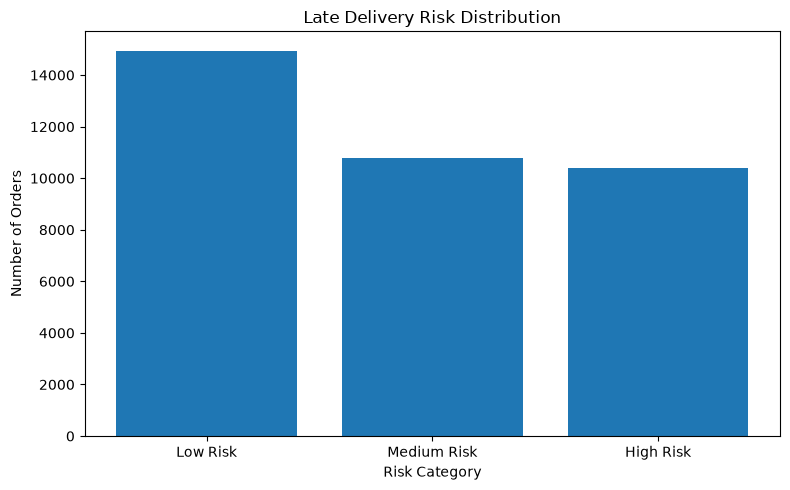

In [88]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["Risk Category"],
    risk_summary["Order Count"]
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Orders")
plt.title("Late Delivery Risk Distribution")

plt.tight_layout()
plt.show()

In [89]:
# Top 10 model features

key_risk_drivers = final_importance_df.head(10).copy()

key_risk_drivers["Importance (%)"] = (
    key_risk_drivers["Importance"] * 100
)

key_risk_drivers = key_risk_drivers[
    ["Feature", "Importance (%)"]
]

key_risk_drivers

,Feature,Importance (%)
1,num__Benefit per order,5.831908
10,num__Order Profit Per Order,5.829828
6,num__Order Item Profit Ratio,5.274508
0,num__Days for shipment (scheduled),4.370691
9,num__Order Item Total,3.884066
2,num__Sales per customer,3.860295
3,num__Order Item Discount,3.821363
16,num__Standard_Class_Flag,3.720227
18,num__Order_Complexity_Score,3.642121
448,cat__Shipping Mode_Standard Class,3.558490


In [90]:
# Create high-risk order list

high_risk_orders_final = final_test_orders[
    final_test_orders["Risk_Category"] == "High Risk"
].copy()

# Preserve original dataframe index as Order Index
high_risk_orders_final = (
    high_risk_orders_final
    .reset_index()
    .rename(columns={"index": "Order Index"})
)

# Select useful operational columns
high_risk_order_list = high_risk_orders_final[
    [
        "Order Index",
        "Late_Delivery_Probability",
        "Risk_Category",
        "Shipping Mode",
        "Market",
        "Order Region",
        "Customer Segment",
        "Days for shipment (scheduled)",
        "Order Item Quantity",
        "Order_Complexity_Score",
        "Shipping Pressure Index",
        "Order Item Discount Rate"
    ]
].copy()

# Sort by highest probability
high_risk_order_list = high_risk_order_list.sort_values(
    "Late_Delivery_Probability",
    ascending=False
)

print("Number of high-risk orders:", len(high_risk_order_list))

high_risk_order_list.head(20)

Number of high-risk orders: 10379


,Order Index,Late_Delivery_Probability,Risk_Category,Shipping Mode,Market,Order Region,Customer Segment,Days for shipment (scheduled),Order Item Quantity,Order_Complexity_Score,Shipping Pressure Index,Order Item Discount Rate
0,83479,1.0,High Risk,First Class,Pacific Asia,Oceania,Consumer,1,1,0.220000,0.5,0.09
1,87363,1.0,High Risk,First Class,Pacific Asia,Eastern Asia,Consumer,1,2,0.320000,1.0,0.09
2,86751,1.0,High Risk,First Class,Pacific Asia,West Asia,Corporate,1,1,0.126667,0.5,0.02
3,2733,1.0,High Risk,First Class,Europe,Western Europe,Consumer,1,1,0.180000,0.5,0.06
4,68117,1.0,High Risk,First Class,LATAM,Caribbean,Consumer,1,3,0.540000,1.5,0.18
5,85104,1.0,High Risk,First Class,Pacific Asia,South Asia,Home Office,1,1,0.433333,0.5,0.25
6,167699,1.0,High Risk,First Class,Europe,Southern Europe,Consumer,1,4,0.466667,2.0,0.05
7,33054,1.0,High Risk,First Class,LATAM,South America,Corporate,1,1,0.153333,0.5,0.04
8,169489,1.0,High Risk,First Class,Africa,East Africa,Consumer,1,1,0.313333,0.5,0.16
9,23924,1.0,High Risk,First Class,Europe,Northern Europe,Home Office,1,1,0.366667,0.5,0.20


In [91]:
# Save KPI outputs

risk_summary.to_csv(
    r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\data\risk_summary.csv",
    index=False
)

key_risk_drivers.to_csv(
    r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\data\key_risk_drivers.csv",
    index=False
)

high_risk_order_list.to_csv(
    r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\data\high_risk_order_list.csv",
    index=False
)

print("KPI files saved successfully.")

KPI files saved successfully.


In [92]:
import os

models_path = r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\models"

os.makedirs(models_path, exist_ok=True)

print("Models folder ready:")
print(models_path)

Models folder ready:
D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\models


In [93]:
import joblib

# Save final Random Forest
joblib.dump(
    final_random_forest,
    os.path.join(models_path, "final_random_forest.pkl")
)

# Save preprocessing pipeline
joblib.dump(
    final_preprocessor,
    os.path.join(models_path, "final_preprocessor.pkl")
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [94]:
model_metadata = {
    "model_name": "Final Random Forest",
    "roc_auc": roc_auc_final,
    "precision": precision_final,
    "recall": recall_final,
    "f1_score": f1_final,
    "low_risk_threshold": 0.40,
    "high_risk_threshold": 0.70,
    "feature_count": X_final.shape[1]
}

joblib.dump(
    model_metadata,
    os.path.join(models_path, "model_metadata.pkl")
)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [95]:
print("Saved model files:")

for file_name in os.listdir(models_path):
    print("-", file_name)

Saved model files:
- final_preprocessor.pkl
- final_random_forest.pkl
- model_input_columns.pkl
- model_metadata.pkl


In [96]:
model_input_columns = X_final.columns.tolist()

joblib.dump(
    model_input_columns,
    os.path.join(models_path, "model_input_columns.pkl")
)

print("Number of model input columns:", len(model_input_columns))
print("\nModel input columns:")
for column in model_input_columns:
    print("-", column)

Number of model input columns: 30

Model input columns:
- Type
- Days for shipment (scheduled)
- Benefit per order
- Sales per customer
- Category Name
- Customer Country
- Customer Segment
- Customer State
- Department Name
- Market
- Order Country
- Order Item Discount
- Order Item Discount Rate
- Order Item Product Price
- Order Item Profit Ratio
- Order Item Quantity
- Sales
- Order Item Total
- Order Profit Per Order
- Order Region
- Product Name
- Product Price
- Shipping Mode
- Shipping Pressure Index
- First_Class_Flag
- Second_Class_Flag
- Same_Day_Flag
- Standard_Class_Flag
- Regional_Congestion_Indicator
- Order_Complexity_Score


In [97]:
import os

project_path = r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction"

app_path = os.path.join(project_path, "app")

os.makedirs(app_path, exist_ok=True)

print("App folder ready:")
print(app_path)

App folder ready:
D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\app


In [98]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Late Delivery Risk Prediction",
    page_icon="📦",
    layout="wide"
)

# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "APL_Logistics.csv"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "final_random_forest.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "models",
    "final_preprocessor.pkl"
)

METADATA_PATH = os.path.join(
    BASE_DIR,
    "models",
    "model_metadata.pkl"
)

# ============================================================
# LOAD DATA AND MODEL
# ============================================================

@st.cache_data
def load_data():

    data = pd.read_csv(
        DATA_PATH,
        encoding="latin1"
    )

    # ========================================================
    # CREATE ENGINEERED FEATURES
    # ========================================================

    # Shipping Pressure Index
    data["Shipping Pressure Index"] = (
        data["Order Item Quantity"]
        / (data["Days for shipment (scheduled)"] + 1)
    )

    # Shipping mode flags
    data["First_Class_Flag"] = (
        data["Shipping Mode"] == "First Class"
    ).astype(int)

    data["Second_Class_Flag"] = (
        data["Shipping Mode"] == "Second Class"
    ).astype(int)

    data["Same_Day_Flag"] = (
        data["Shipping Mode"] == "Same Day"
    ).astype(int)

    data["Standard_Class_Flag"] = (
        data["Shipping Mode"] == "Standard Class"
    ).astype(int)

    # Regional congestion
    region_counts = data["Order Region"].value_counts()

    data["Regional_Congestion_Indicator"] = (
        data["Order Region"].map(region_counts)
    )

    # Order complexity
    quantity_norm = (
        data["Order Item Quantity"]
        / data["Order Item Quantity"].max()
    )

    discount_norm = (
        data["Order Item Discount Rate"]
        / data["Order Item Discount Rate"].max()
    )

    pressure_norm = (
        data["Shipping Pressure Index"]
        / data["Shipping Pressure Index"].max()
    )

    data["Order_Complexity_Score"] = (
        quantity_norm
        + discount_norm
        + pressure_norm
    ) / 3

    return data


@st.cache_resource
def load_model():
    model = joblib.load(MODEL_PATH)
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    metadata = joblib.load(METADATA_PATH)

    return model, preprocessor, metadata


df = load_data()
model, preprocessor, metadata = load_model()
dashboard_predictions = load_dashboard_predictions()

# ============================================================
# TITLE
# ============================================================

st.title("📦 Late Delivery Risk Prediction")
st.markdown(
    """
    **Machine Learning–based Late Delivery Risk Prediction
    in Global Supply Chain Operations**
    """
)

st.divider()

# ============================================================
# SIDEBAR FILTERS
# ============================================================

st.sidebar.header("Dashboard Filters")

shipping_modes = sorted(
    df["Shipping Mode"].dropna().unique()
)

markets = sorted(
    df["Market"].dropna().unique()
)

customer_segments = sorted(
    df["Customer Segment"].dropna().unique()
)

selected_shipping_modes = st.sidebar.multiselect(
    "Shipping Mode",
    shipping_modes,
    default=shipping_modes
)

selected_markets = st.sidebar.multiselect(
    "Market",
    markets,
    default=markets
)

selected_segments = st.sidebar.multiselect(
    "Customer Segment",
    customer_segments,
    default=customer_segments
)

risk_threshold = st.sidebar.slider(
    "High-Risk Probability Threshold",
    min_value=0.50,
    max_value=0.95,
    value=0.70,
    step=0.05
)

# ============================================================
# APPLY FILTERS
# ============================================================

filtered_df = df[
    df["Shipping Mode"].isin(selected_shipping_modes)
    & df["Market"].isin(selected_markets)
    & df["Customer Segment"].isin(selected_segments)
].copy()

# ============================================================
# OVERVIEW
# ============================================================

st.header("1. Delay Risk Overview")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Orders",
        f"{len(filtered_df):,}"
    )

with col2:
    actual_late_rate = (
        filtered_df["Late_delivery_risk"].mean()
        if len(filtered_df) > 0
        else 0
    )

    st.metric(
        "Historical Late Rate",
        f"{actual_late_rate:.1%}"
    )

with col3:
    avg_scheduled_days = (
        filtered_df["Days for shipment (scheduled)"].mean()
        if len(filtered_df) > 0
        else 0
    )

    st.metric(
        "Avg Scheduled Days",
        f"{avg_scheduled_days:.2f}"
    )

with col4:
    st.metric(
        "Model ROC-AUC",
        f"{metadata['roc_auc']:.3f}"
    )

st.subheader("Shipping Mode Distribution")

if len(filtered_df) > 0:
    mode_counts = (
        filtered_df["Shipping Mode"]
        .value_counts()
    )

    st.bar_chart(mode_counts)

# ============================================================
# HISTORICAL REGION & MODE ANALYSIS
# ============================================================

st.header("2. Region & Mode Risk Analysis")

col1, col2 = st.columns(2)

with col1:

    st.subheader("Late Delivery Rate by Shipping Mode")

    mode_risk = (
        filtered_df
        .groupby("Shipping Mode")["Late_delivery_risk"]
        .mean()
        .sort_values(ascending=False)
    )

    st.bar_chart(mode_risk)

with col2:

    st.subheader("Late Delivery Rate by Market")

    market_risk = (
        filtered_df
        .groupby("Market")["Late_delivery_risk"]
        .mean()
        .sort_values(ascending=False)
    )

    st.bar_chart(market_risk)

st.subheader("Late Delivery Rate by Order Region")

region_risk = (
    filtered_df
    .groupby("Order Region")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
)

st.dataframe(
    region_risk.reset_index().rename(
        columns={
            "Late_delivery_risk": "Historical Late Rate"
        }
    ),
    use_container_width=True
)

# ============================================================
# ORDER-LEVEL PREDICTION
# ============================================================

st.header("3. Order-Level Risk Prediction")

st.info(
    "Enter the characteristics of an order before shipment "
    "to estimate its late-delivery risk."
)

st.caption(
    "The model uses the operational information entered below. "
    "For model features that are not directly entered, typical "
    "values from the dataset are used."
)

# ------------------------------------------------------------
# INPUT FORM
# ------------------------------------------------------------

with st.form("order_prediction_form"):

    st.subheader("Order Characteristics")

    col1, col2, col3 = st.columns(3)

    with col1:

        input_type = st.selectbox(
            "Order Type",
            sorted(df["Type"].dropna().unique())
        )

        input_shipping_mode = st.selectbox(
            "Shipping Mode",
            sorted(df["Shipping Mode"].dropna().unique())
        )

        input_market = st.selectbox(
            "Market",
            sorted(df["Market"].dropna().unique())
        )

        input_customer_segment = st.selectbox(
            "Customer Segment",
            sorted(df["Customer Segment"].dropna().unique())
        )

    with col2:

        input_region = st.selectbox(
            "Order Region",
            sorted(df["Order Region"].dropna().unique())
        )

        input_scheduled_days = st.number_input(
            "Days for Shipment (Scheduled)",
            min_value=0,
            max_value=10,
            value=3,
            step=1
        )

        input_quantity = st.number_input(
            "Order Item Quantity",
            min_value=1,
            max_value=100,
            value=1,
            step=1
        )

        input_product_price = st.number_input(
            "Product Price",
            min_value=0.0,
            value=100.0,
            step=1.0
        )

    with col3:

        input_discount = st.number_input(
            "Order Item Discount",
            min_value=0.0,
            value=10.0,
            step=1.0
        )

        input_discount_rate = st.number_input(
            "Order Item Discount Rate",
            min_value=0.0,
            max_value=1.0,
            value=0.10,
            step=0.01
        )

        input_profit_ratio = st.number_input(
            "Order Item Profit Ratio",
            min_value=-1.0,
            max_value=1.0,
            value=0.20,
            step=0.01
        )

        input_benefit = st.number_input(
            "Benefit per Order",
            value=20.0,
            step=1.0
        )

    input_sales_customer = st.number_input(
        "Sales per Customer",
        min_value=0.0,
        value=100.0,
        step=1.0
    )

    predict_button = st.form_submit_button(
        "Predict Late Delivery Risk",
        type="primary"
    )


# ============================================================
# PREDICTION
# ============================================================

if predict_button:

    # --------------------------------------------------------
    # CREATE BASELINE INPUT
    # --------------------------------------------------------

    prediction_input = {}

    # Numerical model features
    numerical_model_features = (
        df[model_columns]
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    # Categorical model features
    categorical_model_features = (
        df[model_columns]
        .select_dtypes(include="object")
        .columns
        .tolist()
    )

    # Use typical values for numerical variables
    for feature in numerical_model_features:

        if feature in df.columns:

            prediction_input[feature] = (
                df[feature].median()
            )

    # Use most common values for categorical variables
    for feature in categorical_model_features:

        if feature in df.columns:

            prediction_input[feature] = (
                df[feature].mode()[0]
            )

    # --------------------------------------------------------
    # OVERWRITE WITH USER INPUTS
    # --------------------------------------------------------

    prediction_input["Type"] = input_type

    prediction_input["Shipping Mode"] = input_shipping_mode

    prediction_input["Market"] = input_market

    prediction_input["Order Region"] = input_region

    prediction_input["Customer Segment"] = input_customer_segment

    prediction_input["Days for shipment (scheduled)"] = (
        input_scheduled_days
    )

    prediction_input["Order Item Quantity"] = (
        input_quantity
    )

    prediction_input["Order Item Product Price"] = (
        input_product_price
    )

    prediction_input["Product Price"] = (
        input_product_price
    )

    prediction_input["Order Item Discount"] = (
        input_discount
    )

    prediction_input["Order Item Discount Rate"] = (
        input_discount_rate
    )

    prediction_input["Order Item Profit Ratio"] = (
        input_profit_ratio
    )

    prediction_input["Benefit per order"] = (
        input_benefit
    )

    prediction_input["Sales per customer"] = (
        input_sales_customer
    )

    # --------------------------------------------------------
    # ENGINEERED FEATURES
    # --------------------------------------------------------

    prediction_input["Shipping Pressure Index"] = (
        input_quantity /
        (input_scheduled_days + 1)
    )

    prediction_input["First_Class_Flag"] = int(
        input_shipping_mode == "First Class"
    )

    prediction_input["Second_Class_Flag"] = int(
        input_shipping_mode == "Second Class"
    )

    prediction_input["Same_Day_Flag"] = int(
        input_shipping_mode == "Same Day"
    )

    prediction_input["Standard_Class_Flag"] = int(
        input_shipping_mode == "Standard Class"
    )

    # Regional congestion
    region_counts = df["Order Region"].value_counts()

    prediction_input["Regional_Congestion_Indicator"] = (
        region_counts.get(
            input_region,
            region_counts.median()
        )
    )

    # Order complexity
    quantity_norm = (
        input_quantity /
        df["Order Item Quantity"].max()
    )

    discount_norm = (
        input_discount_rate /
        df["Order Item Discount Rate"].max()
    )

    pressure_norm = (
        prediction_input["Shipping Pressure Index"] /
        df["Shipping Pressure Index"].max()
    )

    prediction_input["Order_Complexity_Score"] = (
        quantity_norm
        + discount_norm
        + pressure_norm
    ) / 3

    # --------------------------------------------------------
    # CONVERT TO DATAFRAME
    # --------------------------------------------------------

    prediction_input = pd.DataFrame(
        [prediction_input]
    )

    # Ensure exact model column order
    prediction_input = prediction_input[
        model_columns
    ]

    # --------------------------------------------------------
    # MODEL PREDICTION
    # --------------------------------------------------------

    processed_input = preprocessor.transform(
        prediction_input
    )

    probability = model.predict_proba(
        processed_input
    )[0, 1]

    # --------------------------------------------------------
    # RISK CLASSIFICATION
    # --------------------------------------------------------

    if probability < 0.40:

        risk_category = "Low Risk"

    elif probability <= 0.70:

        risk_category = "Medium Risk"

    else:

        risk_category = "High Risk"

    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    st.divider()

    st.subheader("Prediction Result")

    result_col1, result_col2 = st.columns(2)

    with result_col1:

        st.metric(
            "Late Delivery Probability",
            f"{probability:.1%}"
        )

    with result_col2:

        st.metric(
            "Risk Category",
            risk_category
        )

    # --------------------------------------------------------
    # RISK MESSAGE
    # --------------------------------------------------------

    if risk_category == "High Risk":

        st.error(
            "⚠️ High-risk order: proactive operational "
            "review is recommended."
        )

    elif risk_category == "Medium Risk":

        st.warning(
            "⚠️ Medium-risk order: monitor the order "
            "and review available capacity."
        )

    else:

        st.success(
            "✓ Low-risk order: continue standard "
            "operational monitoring."
        )

    # --------------------------------------------------------
    # KEY INPUT FACTORS
    # --------------------------------------------------------

    st.subheader("Key Order Characteristics")

    explanation_col1, explanation_col2 = st.columns(2)

    with explanation_col1:

        st.write(
            f"**Shipping Mode:** "
            f"{input_shipping_mode}"
        )

        st.write(
            f"**Scheduled Shipping Days:** "
            f"{input_scheduled_days}"
        )

        st.write(
            f"**Shipping Pressure Index:** "
            f"{prediction_input['Shipping Pressure Index'].iloc[0]:.3f}"
        )

        st.write(
            f"**Order Quantity:** "
            f"{input_quantity}"
        )

    with explanation_col2:

        st.write(
            f"**Order Complexity Score:** "
            f"{prediction_input['Order_Complexity_Score'].iloc[0]:.3f}"
        )

        st.write(
            f"**Discount Rate:** "
            f"{input_discount_rate:.1%}"
        )

        st.write(
            f"**Order Profit Ratio:** "
            f"{input_profit_ratio:.2f}"
        )

        st.write(
            f"**Order Region:** "
            f"{input_region}"
        )

    st.caption(
        "The prediction represents model output, not a causal "
        "determination that any individual feature will cause "
        "a delivery delay."
    )

# ============================================================
# OPERATIONS ACTION PANEL
# ============================================================

st.header("4. Operations Action Panel")

st.markdown(
    """
    **Suggested operational interpretation**

    - **High Risk:** Review the order and consider proactive intervention.
    - **Medium Risk:** Monitor the order and review available capacity.
    - **Low Risk:** Continue normal processing while maintaining standard monitoring.

    These recommendations are operational guidelines and should be
    combined with current logistics conditions and human judgment.
    """
)

# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Late Delivery Risk Prediction | Unified Mentor Project"
)
'''

app_file = os.path.join(app_path, "app.py")

with open(app_file, "w", encoding="utf-8") as f:
    f.write(app_code)

print("Streamlit application created:")
print(app_file)

Streamlit application created:
D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\app\app.py


In [99]:
# Save all final model predictions for the dashboard

dashboard_predictions = final_test_orders.copy()

dashboard_predictions = dashboard_predictions.reset_index()
dashboard_predictions = dashboard_predictions.rename(
    columns={"index": "Order Index"}
)

dashboard_predictions.to_csv(
    r"D:\LEARNING\unified mentor\project 1\late-delivery-risk-prediction\data\dashboard_predictions.csv",
    index=False
)

print("Dashboard predictions saved.")
print("Shape:", dashboard_predictions.shape)

Dashboard predictions saved.
Shape: (36104, 50)
